# Neural Network, Group 1



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('education_data.csv')
education_data_df

NameError: name 'education_data_df' is not defined

In [9]:
print(education_data_df)

NameError: name 'education_data_df' is not defined

# TASK 1: Data Set Information



#### The title of the data set is "Education Inequality Data". It is focused on data that highlights certain aspects of education inequality including the type of school, funding per student, average testing scores, minority percentages, and more.

#### This data was obtained from \-\- [https://www.kaggle.com/datasets/shamimhasan8/education\-inequality\-data](https://www.kaggle.com/datasets/shamimhasan8/education-inequality-data)

#### The purpose of this data is to analyze the different educational experiences that are dependent on many variables and impact unequal learning opportunities.

#### Dataset Introduction: This dataset contains records for 1000 schools in the United States across 12 states, spanning public, private, and charter institutions at the elementary, middle, and high school levels. Each record captures key resource and demographic indicators, including per\-student funding, student\-teacher ratio, and internet access rates. The student demographic variables \(percent low\-income and percent minority\) reflect wider socioeconomic diversity across schools. Outcome measures include average test scores and dropout rates. This dataset is well\-suited for investigating the relationship between the type of school and the percentage of minority students at that school.



In [6]:
education_data_df = pd.read_csv("education_data.csv")
education_data_df.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


# TASK 2: Basic Data Exploration



In [7]:
education_data_df.head(5)

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [8]:
education_data_df.tail(5)

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
995,996,Hale High School,Ohio,Charter,Elementary,8775.63,51.9,18.3,12.9,61.0,50.5,10.03
996,997,Herrera Elementary School,Georgia,Public,High,24440.93,61.1,19.2,24.8,49.1,89.3,3.11
997,998,Combs High School,New York,Private,Middle,23947.18,94.2,25.2,16.7,51.1,55.8,7.14
998,999,Buckley Elementary School,Illinois,Private,Elementary,6459.87,57.0,17.0,73.6,48.4,64.0,1.21
999,1000,Berg Elementary School,Illinois,Private,Elementary,15471.48,51.6,10.9,31.1,83.9,94.2,1.53


In [9]:
education_data_df.shape

(1000, 12)

In [10]:
education_data_df.columns

Index(['id', 'school_name', 'state', 'school_type', 'grade_level',
       'funding_per_student_usd', 'avg_test_score_percent',
       'student_teacher_ratio', 'percent_low_income', 'percent_minority',
       'internet_access_percent', 'dropout_rate_percent'],
      dtype='object')

### Task 3
#### Task **3.1:** Use df.info\(\) to display data types of each column.



In [11]:
education_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1000 non-null   int64  
 1   school_name              1000 non-null   object 
 2   state                    1000 non-null   object 
 3   school_type              1000 non-null   object 
 4   grade_level              1000 non-null   object 
 5   funding_per_student_usd  1000 non-null   float64
 6   avg_test_score_percent   1000 non-null   float64
 7   student_teacher_ratio    1000 non-null   float64
 8   percent_low_income       1000 non-null   float64
 9   percent_minority         1000 non-null   float64
 10  internet_access_percent  1000 non-null   float64
 11  dropout_rate_percent     1000 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 93.9+ KB


#### Task **3.2:** Identify numerical vs categorical columns.



In [12]:
num_cols = education_data_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = education_data_df.select_dtypes(include=['object', 'category', 'bool']).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numerical columns: ['id', 'funding_per_student_usd', 'avg_test_score_percent', 'student_teacher_ratio', 'percent_low_income', 'percent_minority', 'internet_access_percent', 'dropout_rate_percent']
Categorical columns: ['school_name', 'state', 'school_type', 'grade_level']


#### Task **3.3:** Are there any data types that should be converted? Explain why.



##### No, all the columns containing numerical values have appropriate data types. For example, funding_per_student_usd is currency so it needs to be a float too allow 2 decimal places for cents. Additionallay, the categorical colums have data types of objects which allows the input texts to have things like properties.

In [13]:
# TASK: Descriptive Summary
##### Obtain summary statistics.
##### What do these statistics tell you about numerical columns?
##### Are there any unusual or inconsistent values?
##### df.describe() | df.describe(include=’all’)

### Task 4

#### Task **4.1:** Obtain summary statistics.



In [14]:
education_data_df.describe(include = 'all')

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
count,1000.000000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
unique,NaN,695,10,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Johnson High School,Texas,Private,Elementary,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,119,355,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,NaN,15154.160180,70.001000,19.733200,53.756400,49.652000,74.688500,7.765600
std,288.819436,NaN,NaN,NaN,NaN,5931.384208,17.703408,5.823201,24.021689,25.241025,14.433086,4.214452
min,1.000000,NaN,NaN,NaN,NaN,5012.970000,40.000000,10.000000,10.200000,5.000000,50.000000,0.500000
25%,250.750000,NaN,NaN,NaN,NaN,9726.040000,54.575000,14.800000,33.400000,29.300000,62.400000,4.050000
50%,500.500000,NaN,NaN,NaN,NaN,15362.465000,69.900000,19.400000,54.100000,49.450000,74.750000,7.685000
75%,750.250000,NaN,NaN,NaN,NaN,20280.007500,85.625000,25.000000,74.600000,69.950000,87.325000,11.492500


#### Task **4.2:** What do these statistics tell you about numerical columns?



##### The df.describe\(include = 'all'\) tells us:

##### There's 1000 values under each of the numerical columns. It shows there are no missing values under any of the numerical columns. It also shows us the mean; standard deviation; minimum and maximum values; the 25%, 50%, and 75% quartiles that show the distribution and median of the values.



#### Task **4.3:** Are there any unusual or inconsistent values?



In [15]:
education_data_df.isna().sum()

id                         0
school_name                0
state                      0
school_type                0
grade_level                0
funding_per_student_usd    0
avg_test_score_percent     0
student_teacher_ratio      0
percent_low_income         0
percent_minority           0
internet_access_percent    0
dropout_rate_percent       0
dtype: int64

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

id: 0 outliers
funding_per_student_usd: 0 outliers
avg_test_score_percent: 0 outliers
student_teacher_ratio: 0 outliers
percent_low_income: 0 outliers
percent_minority: 0 outliers
internet_access_percent: 0 outliers
dropout_rate_percent: 0 outliers


There are no outliers or null values in the colunms. So far there are no indications of an unusual or inconsistent values.


In [17]:
# TASK 5: Missing or Duplicate Data
##### Check for missing values in each column.
##### Identify duplicate rows.
##### Provide observations about missing data impact.
##### df.isnull().sum() | df.duplicated().sum()

In [18]:
education_data_df.isnull().sum
education_data_df.duplicated().sum()

0

In [19]:
# TASK 6: Add a New Column
##### Create a new derived column based on existing data.
##### Example: BMI = Weight / Height2
##### Display the first few rows to confirm addition.
##### Briefly explain what this new column represents.

In [20]:
education_data_df["dropout_status"] = np.select(
    [
        education_data_df["dropout_rate_percent"] > 10,
        education_data_df["dropout_rate_percent"] < 5
    ],
    [
        "High Dropout",
        "Low Dropout"
    ],
    default="Moderate"
)
education_data_df

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent,dropout_status
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44,Low Dropout
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67,Moderate
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75,High Dropout
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45,High Dropout
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Hale High School,Ohio,Charter,Elementary,8775.63,51.9,18.3,12.9,61.0,50.5,10.03,High Dropout
996,997,Herrera Elementary School,Georgia,Public,High,24440.93,61.1,19.2,24.8,49.1,89.3,3.11,Low Dropout
997,998,Combs High School,New York,Private,Middle,23947.18,94.2,25.2,16.7,51.1,55.8,7.14,Moderate
998,999,Buckley Elementary School,Illinois,Private,Elementary,6459.87,57.0,17.0,73.6,48.4,64.0,1.21,Low Dropout


In [21]:
# TASK 7: Filter the Data
##### Apply at least two different filters to extract subsets.
##### Display the filtered results.
##### Explain what subsets were created and why they are interesting.
##### df[df[’column’] > value] | df.query(’condition’)

In [22]:
A_score_highschool = education_data_df.query("grade_level == 'High' and avg_test_score_percent >= 90")

A_score_highschool.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent,dropout_status
67,68,Dean Middle School,Georgia,Charter,High,10475.16,99.9,10.2,59.4,46.8,97.4,12.77,High Dropout
71,72,Mann Elementary School,North Carolina,Public,High,6576.76,95.7,19.3,59.5,35.1,86.9,4.82,Low Dropout
79,80,Moore High School,Pennsylvania,Private,High,19502.61,96.1,20.3,39.4,35.8,96.4,3.31,Low Dropout
106,107,Allen High School,California,Charter,High,21306.52,95.5,20.2,59.3,60.5,89.2,9.69,Moderate
114,115,White High School,Michigan,Charter,High,20476.62,91.7,14.3,70.9,52.8,92.3,5.09,Moderate


In [23]:
highfund_highschool = education_data_df.query("grade_level == 'High' and funding_per_student_usd >= 20000")
highfund_highschool.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent,dropout_status
7,8,Boyd High School,Georgia,Private,High,24162.52,66.9,23.4,66.2,33.9,90.4,8.54,Moderate
12,13,Smith High School,California,Public,High,22343.11,59.4,13.9,61.8,13.7,88.3,8.66,Moderate
26,27,Johnson High School,Texas,Public,High,21981.75,43.5,25.4,93.7,49.8,59.2,11.23,High Dropout
54,55,Petersen Middle School,New York,Private,High,21626.14,75.5,18.1,81.7,50.7,90.9,14.17,High Dropout
77,78,Garcia High School,Pennsylvania,Private,High,24602.03,46.8,13.5,71.2,71.6,73.5,11.50,High Dropout


## Task 7 Explanation

### 2 Filters

- One filter creates a subset showing only high schools that have a A grade average
- The other filter creates a subset showing only high schools that have 20k or more in funding

### Explanation
I just wanted to briefly explore the filtered data and see if there were any quick patterns I could find. I saw from looking at the first 5 values the schools  saw schools that had higher funding, so I just looked at the next subset and I saw that there may not be a as strong correlation between funding an average grade percentage as I had thought, just from looking at the first five values of the second filtered subset

In [24]:
# TASK 8: Unique Values and Categories
##### List unique values or categories for categorical columns.
##### Identify categorical variables important for analysis or grouping.
##### df[’column’].unique() | df[’column’].value_counts()

In [25]:
# Categorical columns
categorical_cols = ['state', 'school_type', 'grade_level']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("\nValue counts:")
    print(df[col].value_counts())


Column: state
Unique values: ['Michigan' 'New York' 'Texas' 'Pennsylvania' 'Georgia' 'Illinois'
 'California' 'North Carolina' 'Ohio' 'Florida']

Value counts:
state
Texas             119
Florida           110
Georgia           107
Illinois          102
Ohio              101
California         97
North Carolina     96
New York           95
Michigan           89
Pennsylvania       84
Name: count, dtype: int64

Column: school_type
Unique values: ['Private' 'Charter' 'Public']

Value counts:
school_type
Private    355
Charter    326
Public     319
Name: count, dtype: int64

Column: grade_level
Unique values: ['High' 'Middle' 'Elementary']

Value counts:
grade_level
Elementary    345
High          330
Middle        325
Name: count, dtype: int64


In [26]:
# TASK 9: Initial Observations
##### Write a short paragraph summarizing:
##### What you found interesting about the dataset.
##### Any patterns, issues, or questions that emerged during exploration.
##### Think critically about what the data reveals...

### **During our exploration of the dataset, we found it interesting how educational factors vary across different states, school types, and grade levels. States such as Texas and Florida have a higher number of schools represented in the dataset, while others like Pennsylvania and Michigan have fewer. The distribution of school types shows a relatively balanced mix of private, charter, and public schools, which allows for meaningful comparisons between them. We also noticed that elementary schools appear slightly more frequently than middle and high schools, which may influence overall trends in the data. These patterns suggest that location, school type, and grade level could all play a role in understanding educational inequality. One question that emerged is how these categories relate to outcomes such as funding, test scores, or dropout rates. Overall, the dataset highlights potential disparities in education that warrant further analysis.**


### Visualization 1: Distribution of Average Test Scores

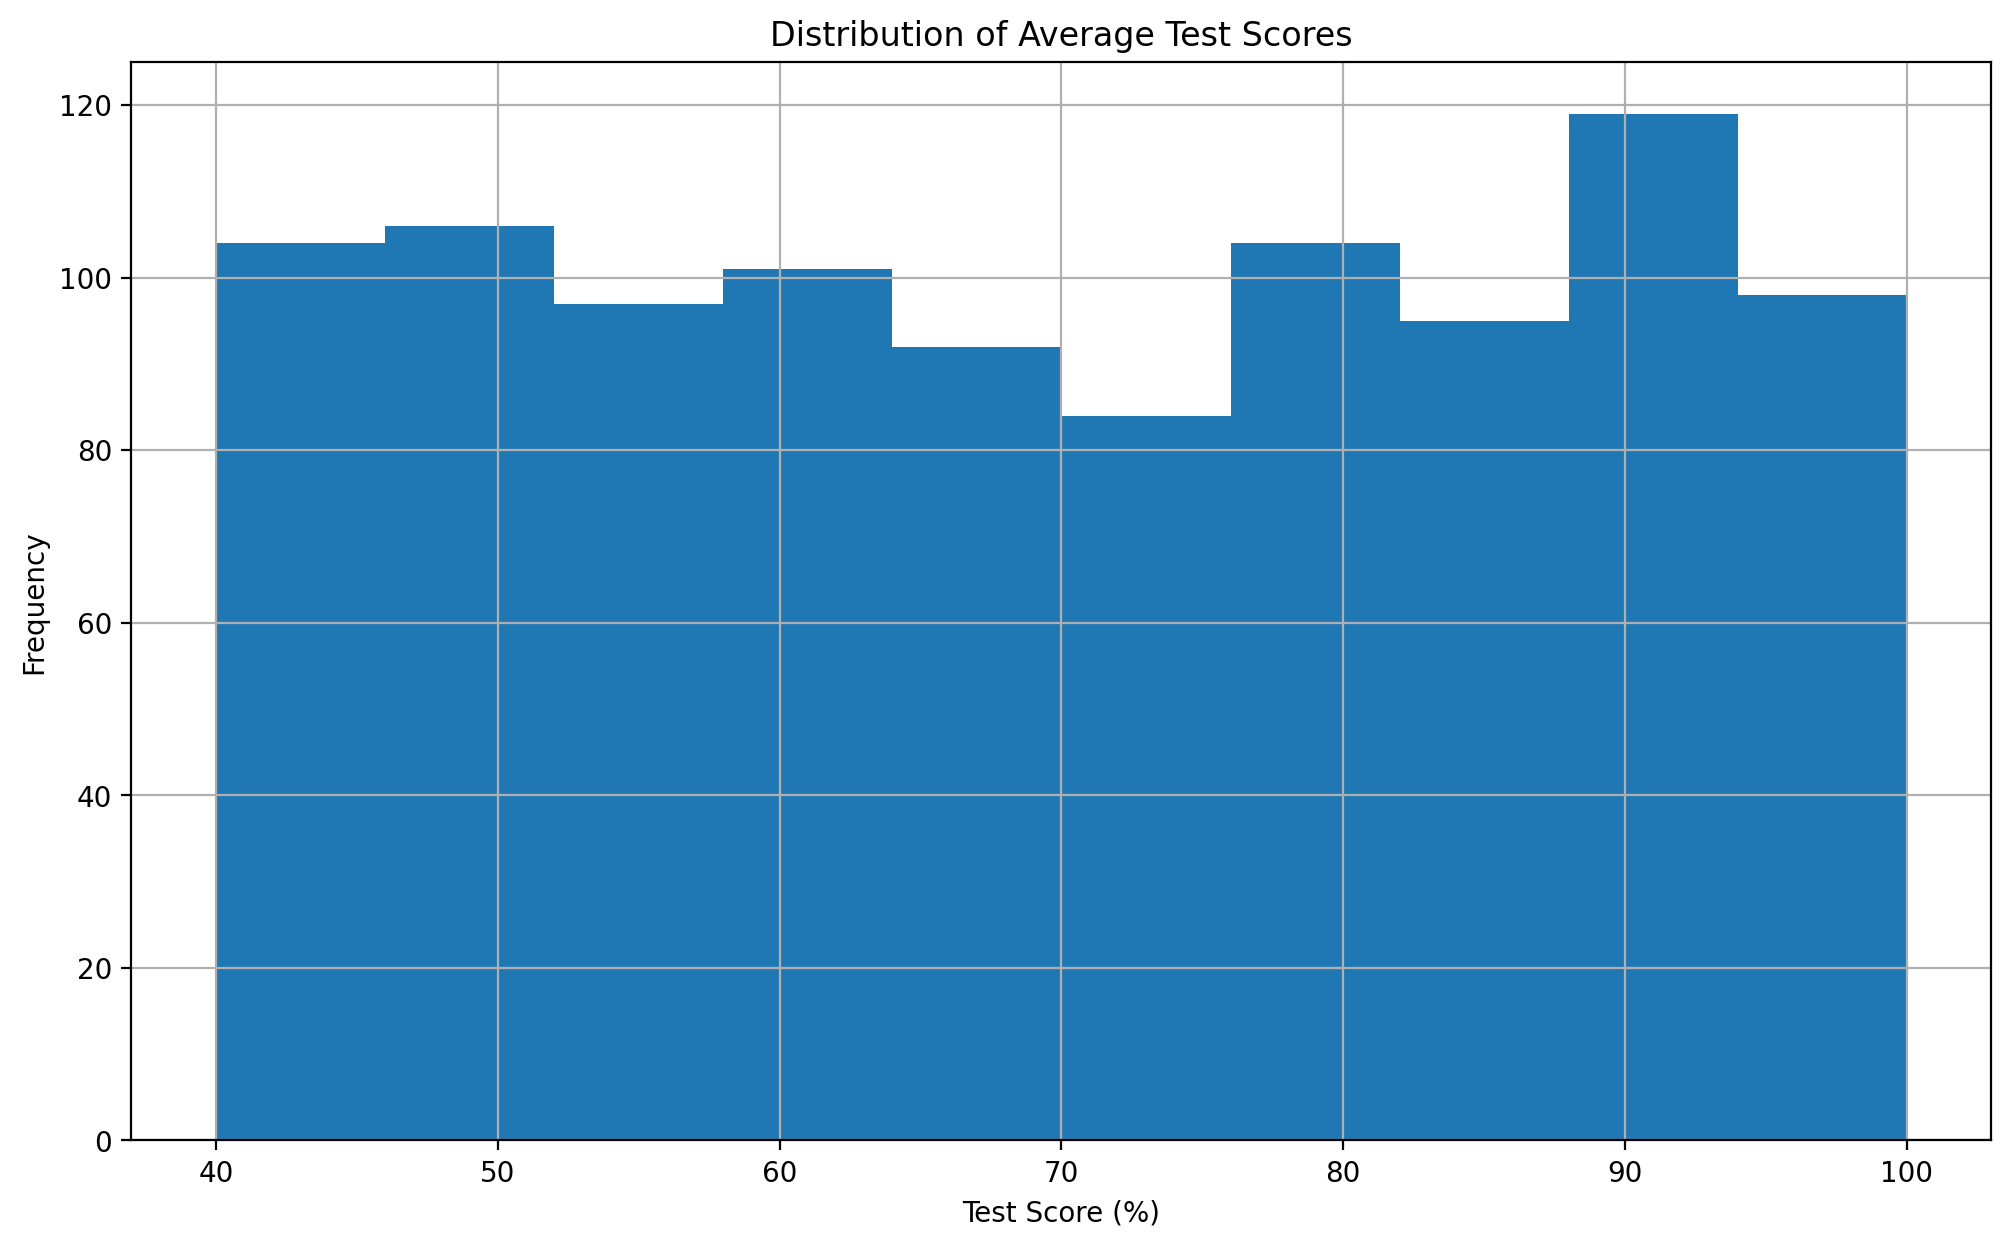

In [27]:
plt.figure()
df['avg_test_score_percent'].hist()
plt.title("Distribution of Average Test Scores")
plt.xlabel("Test Score (%)")
plt.ylabel("Frequency")
plt.show()

This histogram displays the distribution of average test scores across schools. The majority of scores are concentrated in the mid-range, approximately between 60% and 80%, indicating that most schools perform at an average level. There are fewer schools with extremely high or low scores, suggesting that extreme performance is less common. This distribution highlights overall trends in student achievement and provides a baseline for comparing other factors such as funding and demographics.

### Visualization 2: Distribution of School Types

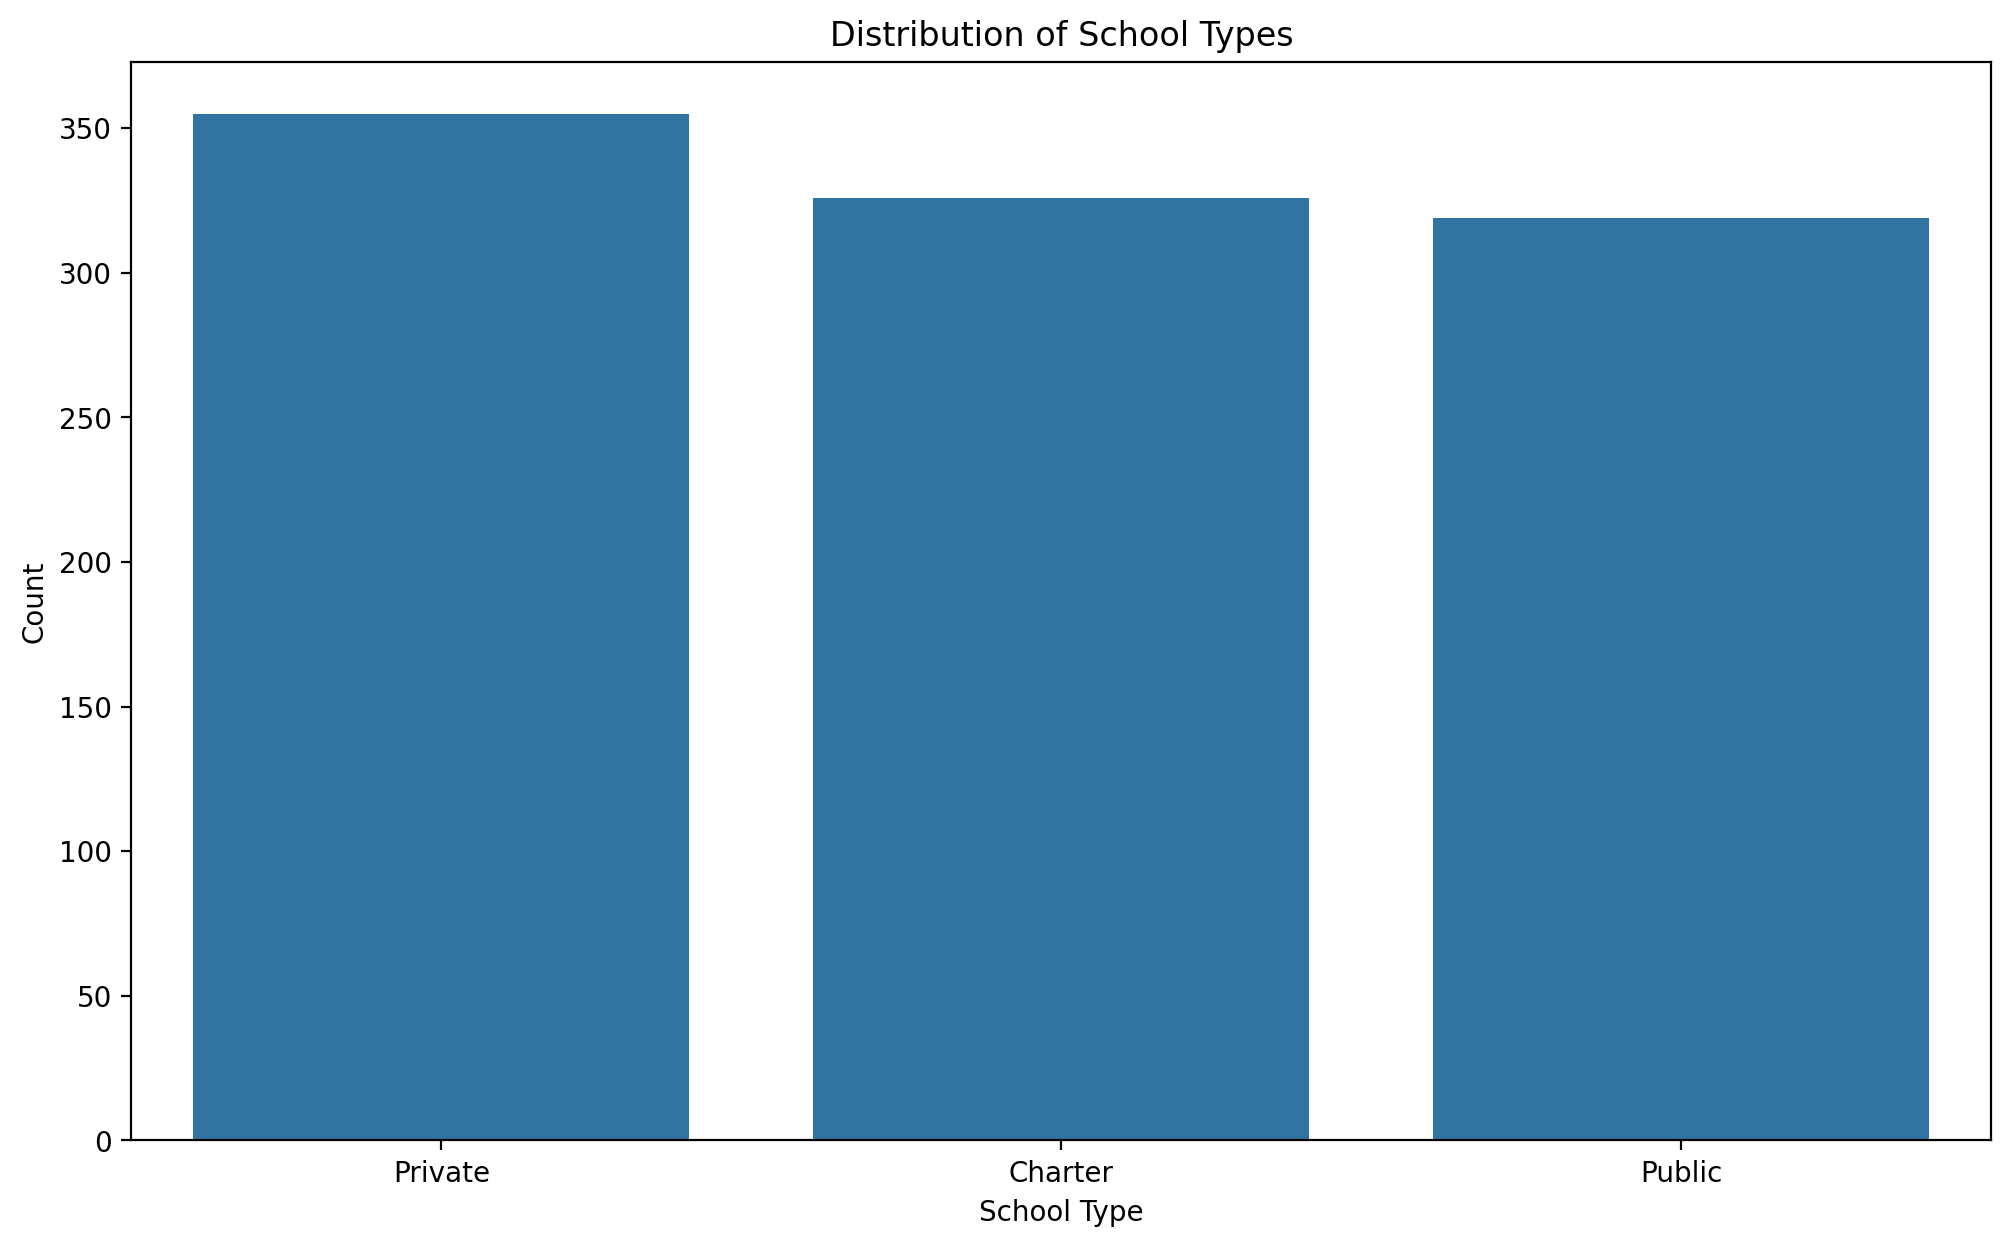

In [28]:
plt.figure()
sns.countplot(x='school_type', data=df)
plt.title("Distribution of School Types")
plt.xlabel("School Type")
plt.ylabel("Count")
plt.show()

This count plot shows the distribution of schools by type, including public, private, and charter institutions. The visualization reveals a relatively balanced distribution among the three categories, with private schools appearing slightly more frequently. This balance allows for meaningful comparisons across school types in further analysis, particularly when examining differences in funding, performance, and dropout rates.



### Visualization 3: Average Funding per Student by School Type

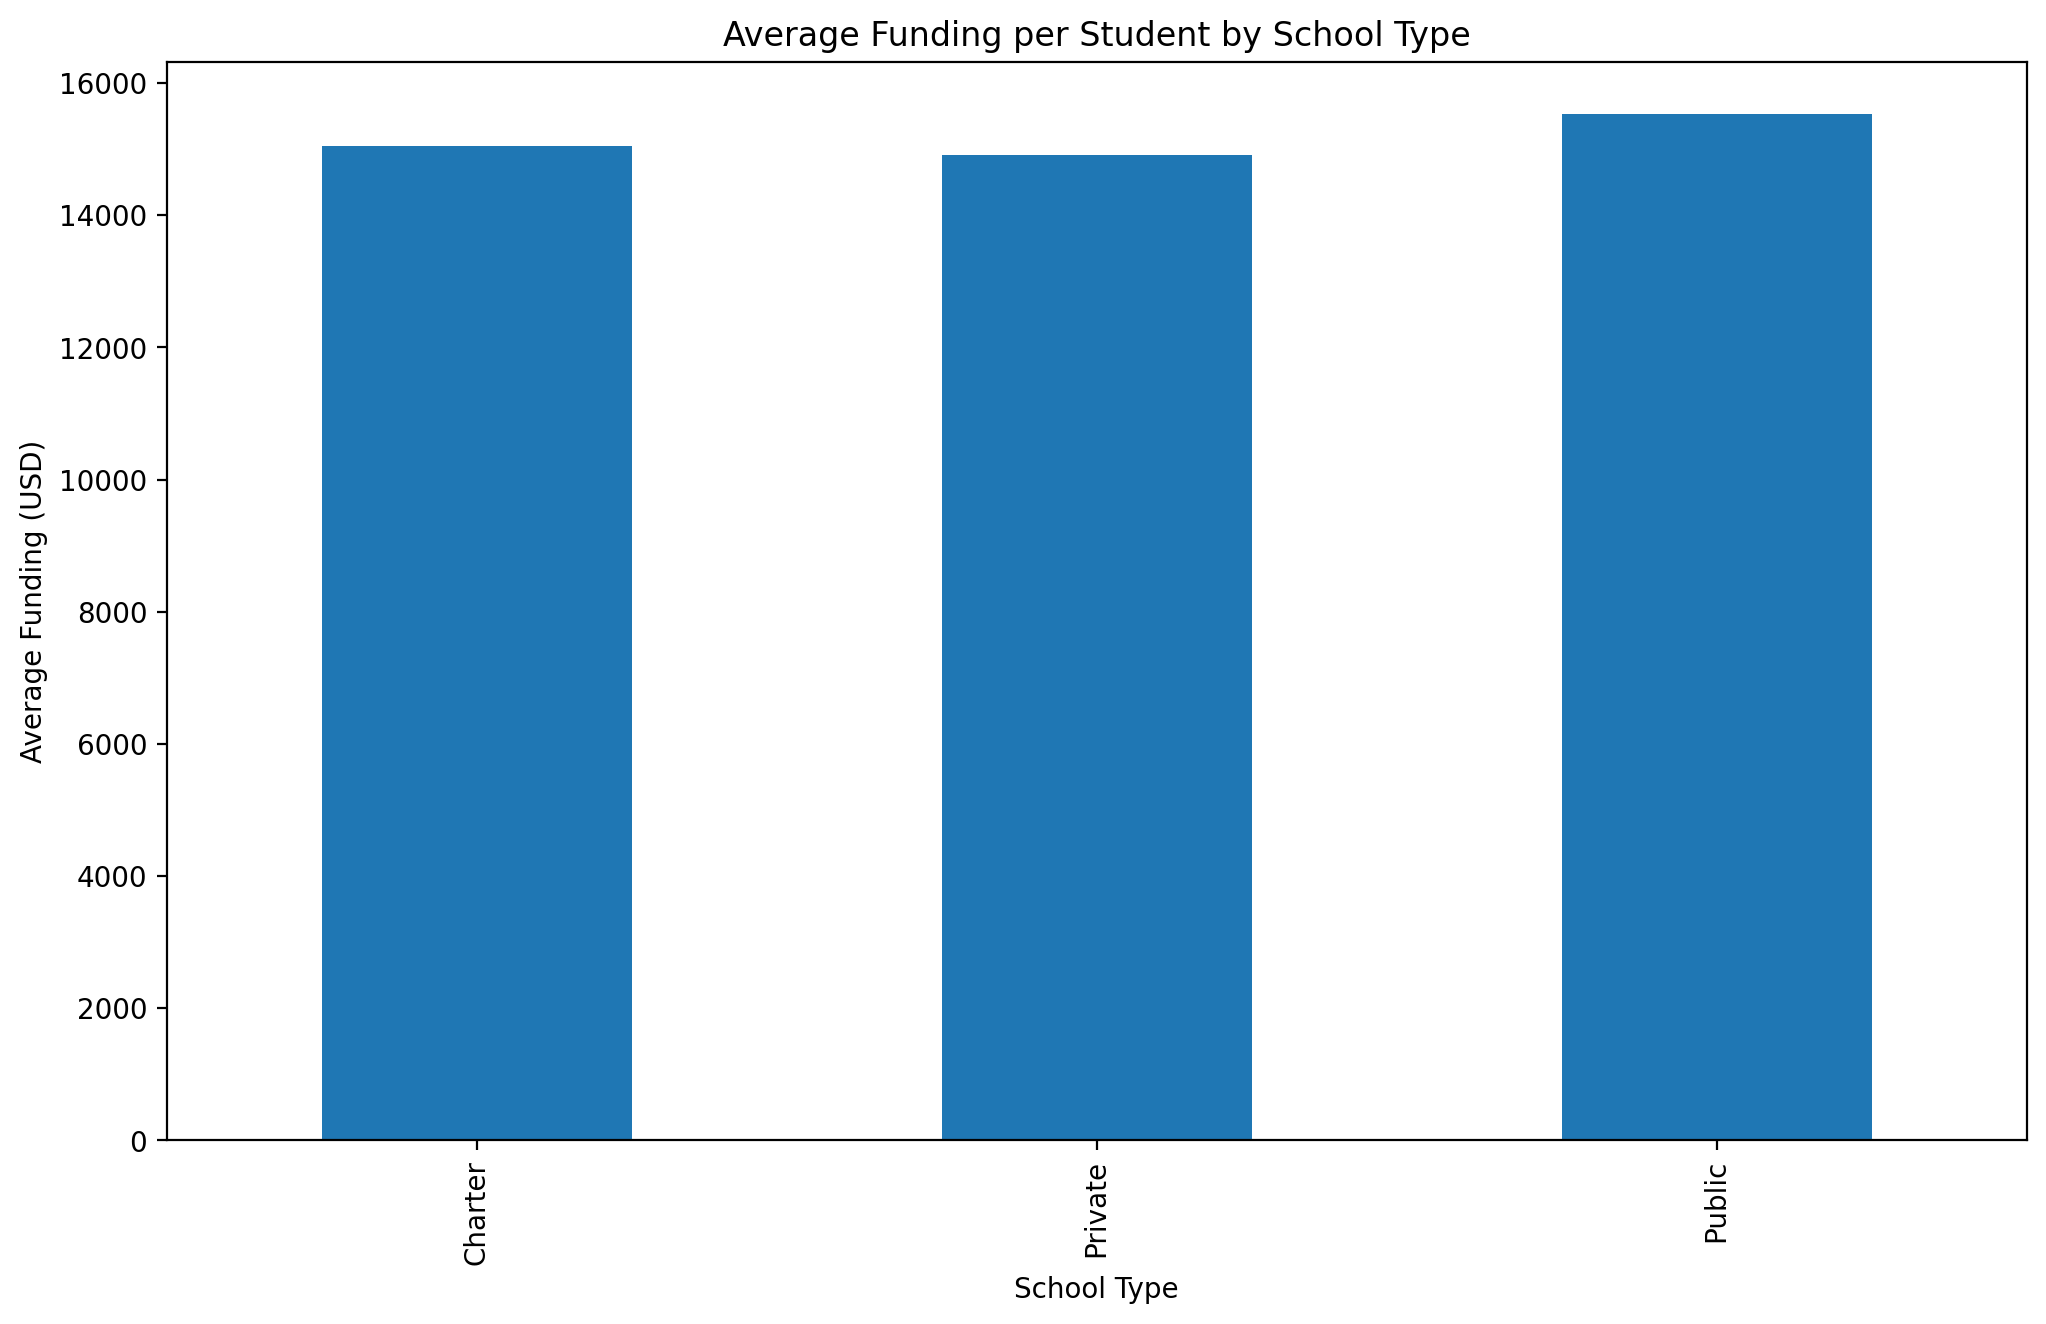

In [29]:
plt.figure()

df.groupby('school_type')['funding_per_student_usd'].mean().plot(kind='bar')

plt.title("Average Funding per Student by School Type")
plt.xlabel("School Type")
plt.ylabel("Average Funding (USD)")
plt.show()

This bar chart compares the average funding per student across different school types. The visualization shows that Public schools receive the highest average funding, while Private schools receive the lowest. This suggests that school type may influence the level of financial resources available to students. These differences in funding could impact educational quality and student outcomes.

### Visualization 4: Relationship Between Funding and Test Scores

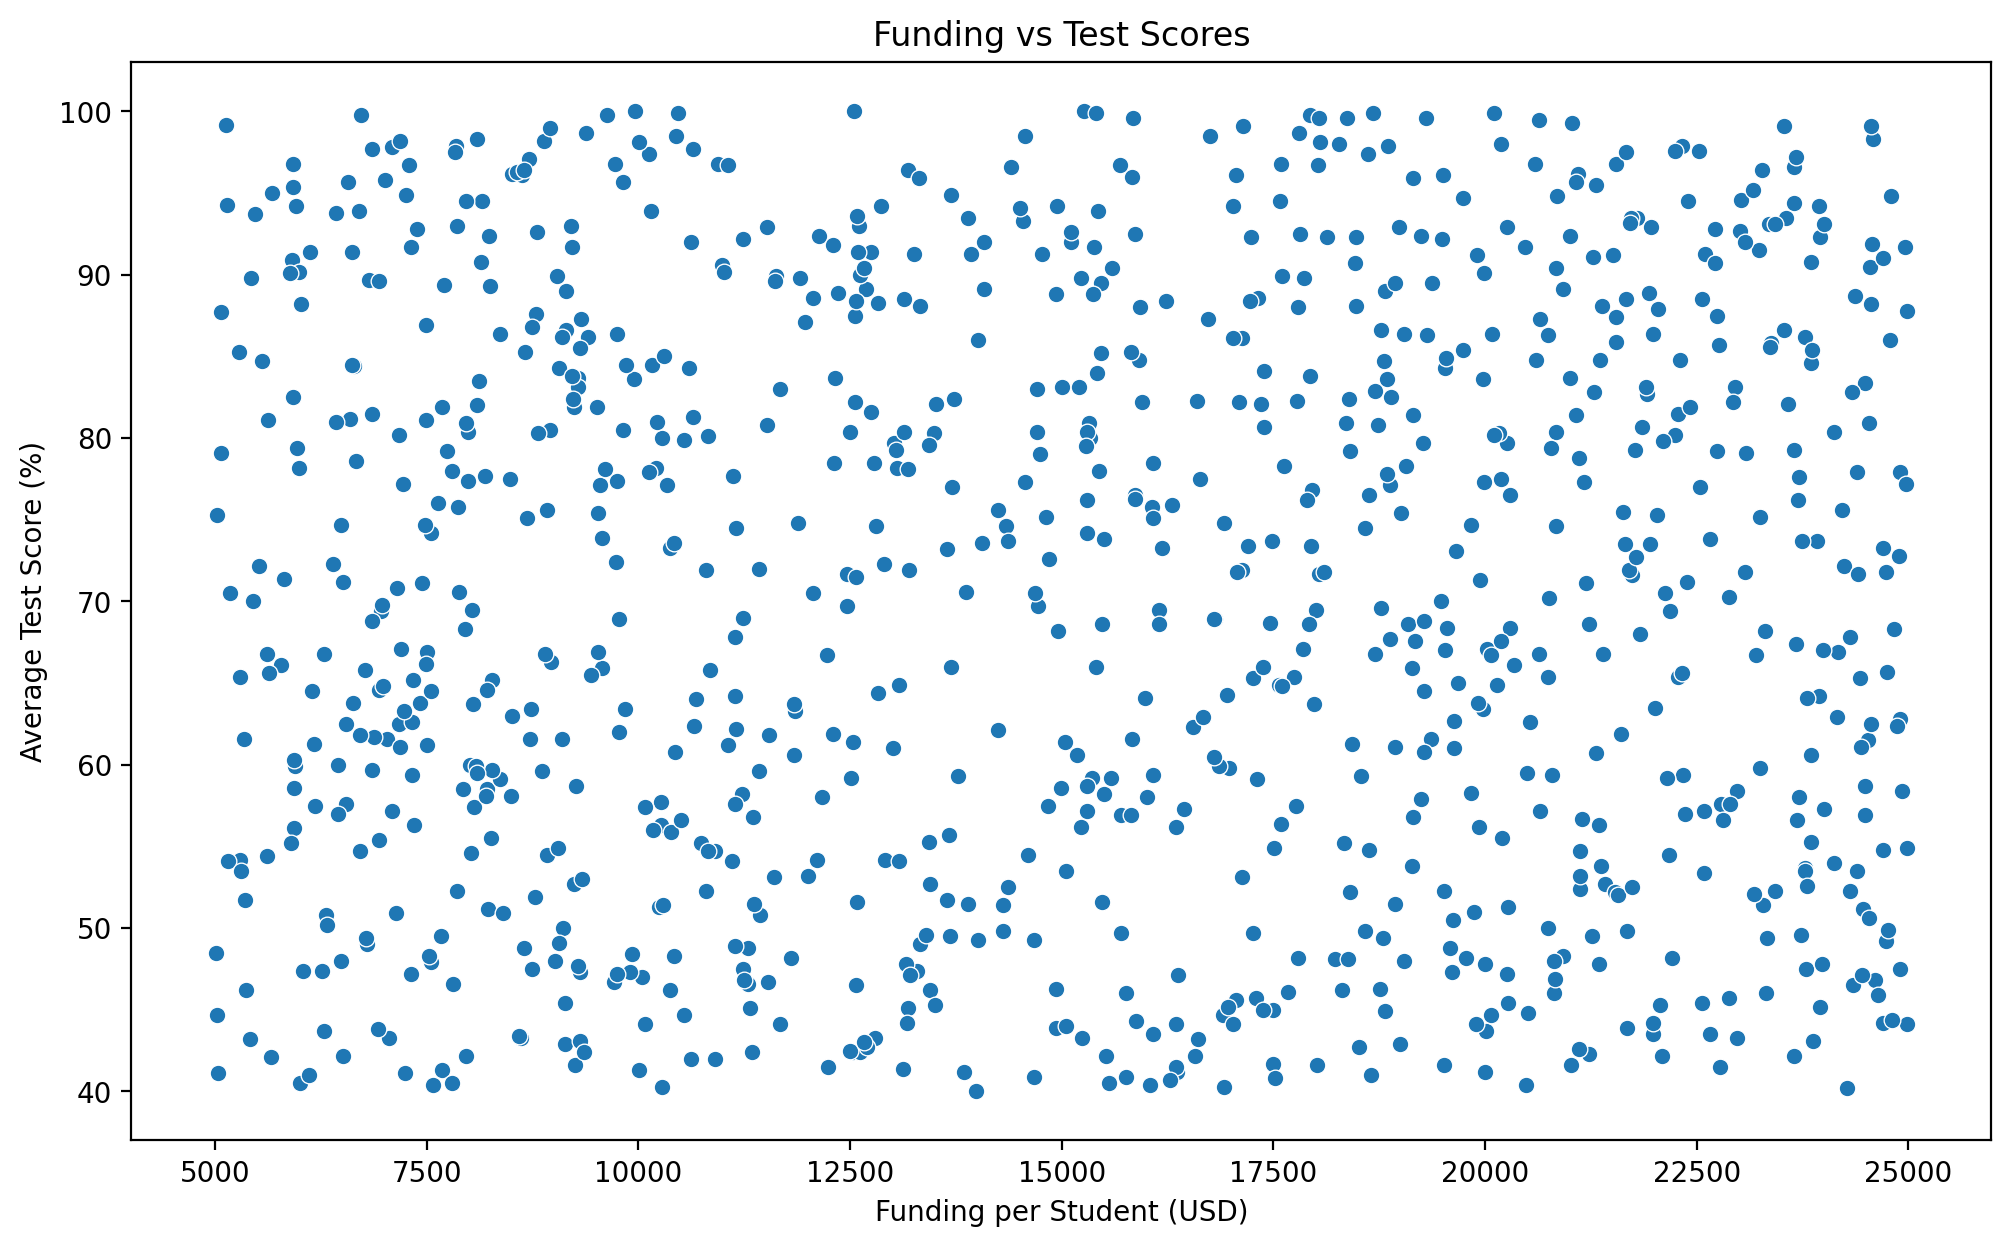

In [30]:
plt.figure()

sns.scatterplot(x='funding_per_student_usd', y='avg_test_score_percent', data=df)

plt.title("Funding vs Test Scores")
plt.xlabel("Funding per Student (USD)")
plt.ylabel("Average Test Score (%)")
plt.show()

This scatter plot shows the relationship between funding per student and average test scores. The data points are widely dispersed across the graph with no clear upward or downward trend, indicating a very weak or no strong correlation between funding and academic performance. Schools with both low and high funding levels exhibit a wide range of test scores. This suggests that increased funding alone does not guarantee higher student achievement, and that other factors such as socioeconomic conditions or school environment may also play a significant role.

### Visualization 5: Correlation Heatmap

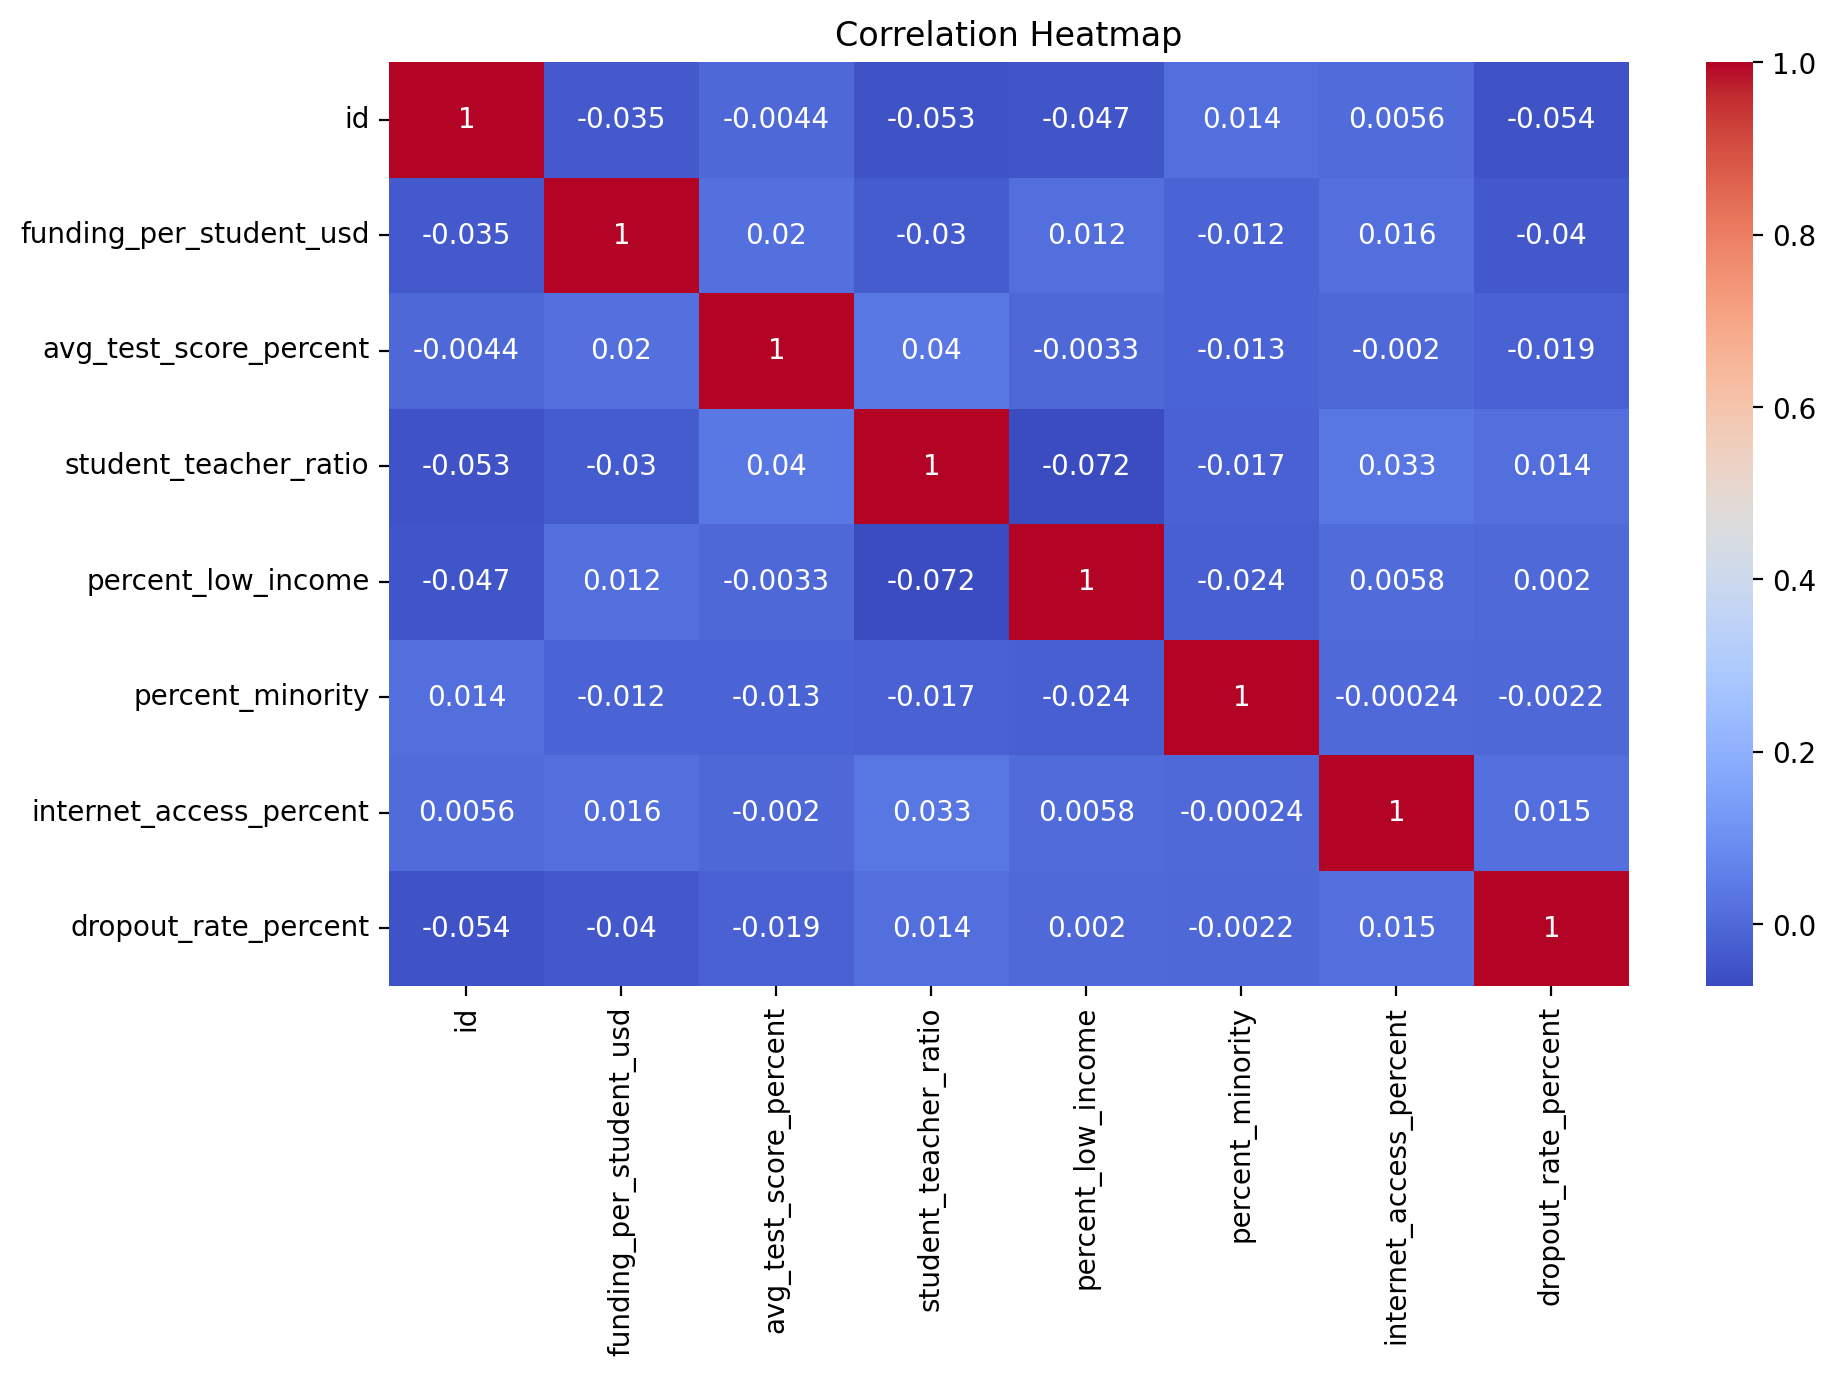

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that most variables have very weak correlations with each other, as the values are close to zero. This indicates that no single factor, such as funding or demographics, strongly predicts student outcomes on its own. Instead, educational outcomes are likely influenced by a combination of multiple factors.

